# PCA + ANN Face Recognition System

## 1. Introduction

This project implements a face recognition system using Principal Component Analysis (PCA) and an Artificial Neural Network (ANN).

PCA is used to reduce the dimensionality of facial images and generate compact face representations called eigenfaces. These representations are then used as input features for an ANN classifier.

The system is evaluated using face recognition accuracy, confusion matrix, classification report, and an additional imposter detection experiment.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
FACE_DATASET_PATH = r"C:\Users\HP\Downloads\dataset\dataset\faces"

print("Dataset path:")
print(FACE_DATASET_PATH)

print("\nPath exists:", os.path.exists(FACE_DATASET_PATH))

Dataset path:
C:\Users\HP\Downloads\dataset\dataset\faces

Path exists: True


In [3]:
person_folders = [
    folder for folder in os.listdir(FACE_DATASET_PATH)
    if os.path.isdir(os.path.join(FACE_DATASET_PATH, folder))
]

print("Number of persons:", len(person_folders))
print("\nPerson folders:")

for folder in person_folders:
    print(folder)

Number of persons: 9

Person folders:
Aamir
Ajay
Akshay
Alia
Amitabh
Deepika
Disha
Farhan
Ileana


In [4]:
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

print("Images per person:\n")

for person in person_folders:
    person_path = os.path.join(FACE_DATASET_PATH, person)

    images = [
        file for file in os.listdir(person_path)
        if file.lower().endswith(image_extensions)
    ]

    print(f"{person}: {len(images)} images")

Images per person:

Aamir: 50 images
Ajay: 50 images
Akshay: 50 images
Alia: 50 images
Amitabh: 50 images
Deepika: 50 images
Disha: 50 images
Farhan: 50 images
Ileana: 50 images


In [5]:
first_person = person_folders[0]

person_path = os.path.join(FACE_DATASET_PATH, first_person)

first_image_file = [
    file for file in os.listdir(person_path)
    if file.lower().endswith(image_extensions)
][0]

first_image_path = os.path.join(person_path, first_image_file)

image = cv2.imread(first_image_path)

print("Person:", first_person)
print("Image:", first_image_file)
print("Image shape:", image.shape)

Person: Aamir
Image: face_101.jpg
Image shape: (199, 199, 3)


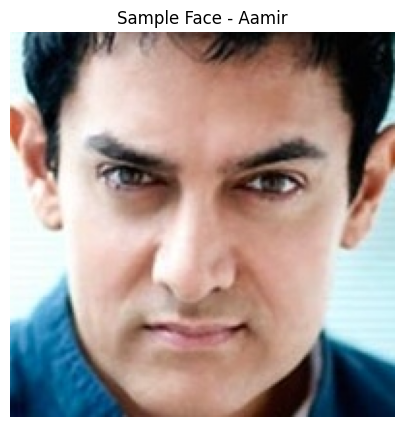

In [6]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(image_rgb)
plt.title(f"Sample Face - {first_person}")
plt.axis("off")
plt.show()

In [8]:
# Image size
IMG_SIZE = (100, 100)

face_data = []
labels = []
label_names = {}

# Assign a numeric label to each person
for label, person in enumerate(person_folders):
    label_names[label] = person

    person_path = os.path.join(FACE_DATASET_PATH, person)

    for file in os.listdir(person_path):

        if file.lower().endswith(image_extensions):

            image_path = os.path.join(person_path, file)

            # Read image in grayscale
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            # Resize image
            img = cv2.resize(img, IMG_SIZE)

            # Convert image to 1D vector
            img_vector = img.flatten()

            face_data.append(img_vector)
            labels.append(label)

face_data = np.array(face_data)
labels = np.array(labels)

print("Face Database Shape:", face_data.shape)
print("Labels Shape:", labels.shape)
print("Number of Images:", len(face_data))
print("Number of Persons:", len(label_names))

Face Database Shape: (450, 10000)
Labels Shape: (450,)
Number of Images: 450
Number of Persons: 9


In [9]:
# Split dataset into 60% training and 40% testing

X_train, X_test, y_train, y_test = train_test_split(
    face_data,
    labels,
    test_size=0.40,
    random_state=42,
    stratify=labels
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (270, 10000)
Testing data shape: (180, 10000)
Training labels shape: (270,)
Testing labels shape: (180,)


In [10]:
# Calculate the mean face

mean_face = np.mean(X_train, axis=0)

print("Mean face shape:", mean_face.shape)

Mean face shape: (10000,)


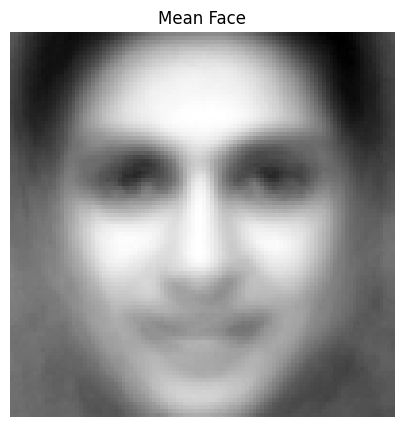

In [11]:
# Display Mean Face

mean_face_image = mean_face.reshape(IMG_SIZE)

plt.figure(figsize=(5, 5))
plt.imshow(mean_face_image, cmap='gray')
plt.title("Mean Face")
plt.axis("off")
plt.show()

In [12]:
# Mean-zero face data

X_train_centered = X_train - mean_face

print("Centered training data shape:", X_train_centered.shape)

Centered training data shape: (270, 10000)


In [13]:
print("Testing data shape:", X_test.shape)
print("Mean face shape:", mean_face.shape)
print("Centered training data shape:", X_train_centered.shape)

Testing data shape: (180, 10000)
Mean face shape: (10000,)
Centered training data shape: (270, 10000)


In [14]:
# Calculate surrogate covariance matrix

covariance_matrix = np.dot(
    X_train_centered,
    X_train_centered.T
)

print("Covariance matrix shape:", covariance_matrix.shape)

Covariance matrix shape: (270, 270)


In [15]:
# Calculate eigenvalues and eigenvectors

eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues shape: (270,)
Eigenvectors shape: (270, 270)


In [16]:
# Sort eigenvalues in descending order

sorted_indices = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

print("Top 10 eigenvalues:")
print(sorted_eigenvalues[:10])

Top 10 eigenvalues:
[1.67129462e+09 1.18813485e+09 8.66562671e+08 4.93455902e+08
 4.50914190e+08 2.71936009e+08 2.39221797e+08 2.15673075e+08
 1.86404864e+08 1.77218995e+08]


In [17]:
# Calculate explained variance ratio

total_variance = np.sum(sorted_eigenvalues)

explained_variance_ratio = sorted_eigenvalues / total_variance

cumulative_variance = np.cumsum(explained_variance_ratio)

print("Cumulative variance for first 10 components:")

for i in range(10):
    print(f"Component {i+1}: {cumulative_variance[i]*100:.2f}%")

Cumulative variance for first 10 components:
Component 1: 19.32%
Component 2: 33.06%
Component 3: 43.07%
Component 4: 48.78%
Component 5: 53.99%
Component 6: 57.13%
Component 7: 59.90%
Component 8: 62.39%
Component 9: 64.55%
Component 10: 66.60%


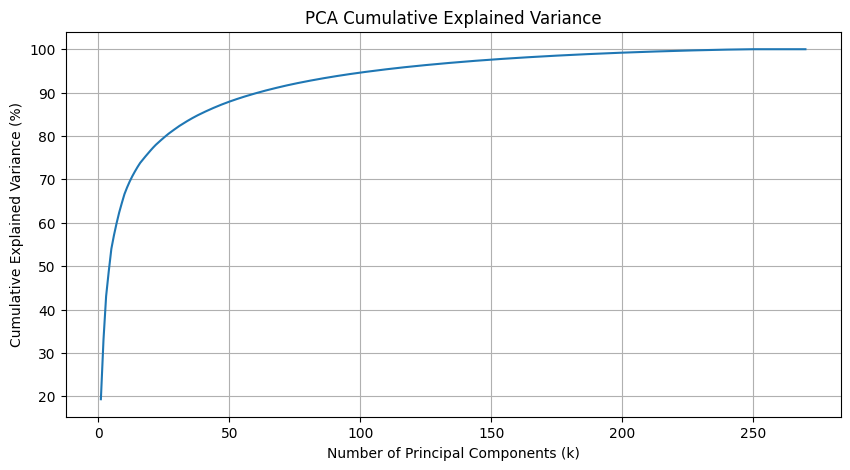

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100
)

plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA Cumulative Explained Variance")

plt.grid(True)
plt.show()

In [19]:
k_values = [5, 10, 15, 20, 25, 30, 40, 50]

print("K values to be tested:")
print(k_values)

K values to be tested:
[5, 10, 15, 20, 25, 30, 40, 50]


In [20]:
k_values = [5, 10, 15, 20, 25, 30, 40, 50]

print("K values to be tested:")
print(k_values)

K values to be tested:
[5, 10, 15, 20, 25, 30, 40, 50]


In [22]:
def generate_eigenfaces(k):
    # Select top k eigenvectors
    selected_eigenvectors = sorted_eigenvectors[:, :k]
    
    # Generate eigenfaces
    eigenfaces = np.dot(
        selected_eigenvectors.T,
        X_train_centered
    )
    
    return eigenfaces

print("Function created successfully!")

Function created successfully!


In [23]:
k = 20

eigenfaces = generate_eigenfaces(k)

print("K:", k)
print("Eigenfaces shape:", eigenfaces.shape)

K: 20
Eigenfaces shape: (20, 10000)


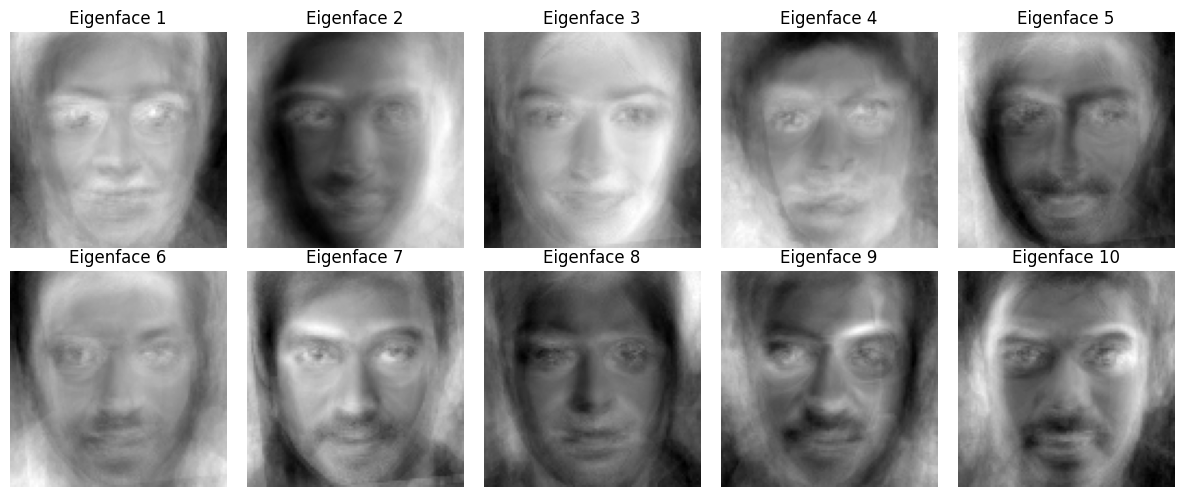

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.ravel()):
    eigenface = eigenfaces[i].reshape(IMG_SIZE)
    
    ax.imshow(eigenface, cmap='gray')
    ax.set_title(f"Eigenface {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
# Generate signatures for training faces

train_signatures = np.dot(
    X_train_centered,
    eigenfaces.T
)

print("Training signatures shape:", train_signatures.shape)

Training signatures shape: (270, 20)


In [30]:
# Mean-center the testing faces

X_test_centered = X_test - mean_face

print("Centered testing data shape:", X_test_centered.shape)

Centered testing data shape: (180, 10000)


In [31]:
# Generate signatures for testing faces

test_signatures = np.dot(
    X_test_centered,
    eigenfaces.T
)

print("Testing signatures shape:", test_signatures.shape)

Testing signatures shape: (180, 20)


In [32]:
ann_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

print("ANN model created successfully!")

ANN model created successfully!


In [33]:
ann_model.fit(train_signatures, y_train)

print("ANN training completed!")

ANN training completed!


In [34]:
y_pred = ann_model.predict(test_signatures)

accuracy = accuracy_score(y_test, y_pred)

print(f"Face Recognition Accuracy: {accuracy * 100:.2f}%")

Face Recognition Accuracy: 57.22%


In [36]:
k_values = [5, 10, 15, 20, 25, 30, 40, 50]

accuracies = []

for k in k_values:

    # Select top k eigenvectors of surrogate covariance matrix
    selected_small_eigenvectors = sorted_eigenvectors[:, :k]

    # Convert them into eigenfaces in original image space
    eigenfaces_k = np.dot(
        selected_small_eigenvectors.T,
        X_train_centered
    )

    # Normalize eigenfaces
    eigenfaces_k = eigenfaces_k / (
        np.linalg.norm(eigenfaces_k, axis=1, keepdims=True) + 1e-10
    )

    # Generate training face signatures
    train_signatures_k = np.dot(
        X_train_centered,
        eigenfaces_k.T
    )

    # Generate testing face signatures
    test_signatures_k = np.dot(
        X_test_centered,
        eigenfaces_k.T
    )

    # Create ANN
    ann = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    )

    # Train ANN
    ann.fit(train_signatures_k, y_train)

    # Predict test faces
    predictions = ann.predict(test_signatures_k)

    # Accuracy
    acc = accuracy_score(y_test, predictions)

    accuracies.append(acc * 100)

    print(f"k = {k:2d}  →  Accuracy = {acc * 100:.2f}%")
    

k =  5  →  Accuracy = 36.11%
k = 10  →  Accuracy = 40.00%
k = 15  →  Accuracy = 43.33%
k = 20  →  Accuracy = 46.67%
k = 25  →  Accuracy = 50.00%
k = 30  →  Accuracy = 47.78%
k = 40  →  Accuracy = 52.78%
k = 50  →  Accuracy = 48.89%


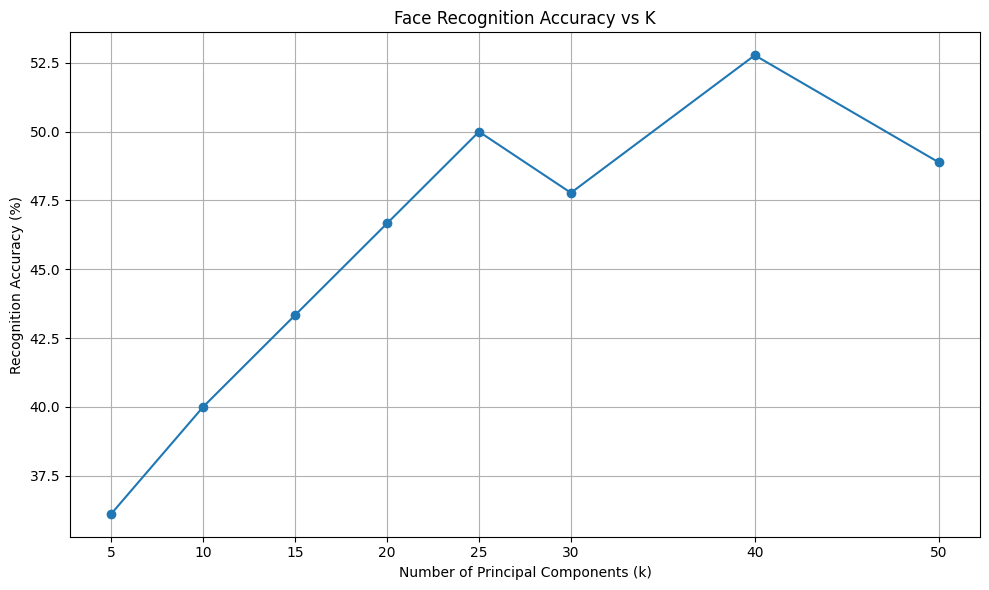

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    accuracies,
    marker='o'
)

plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Recognition Accuracy (%)")
plt.title("Face Recognition Accuracy vs K")

plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

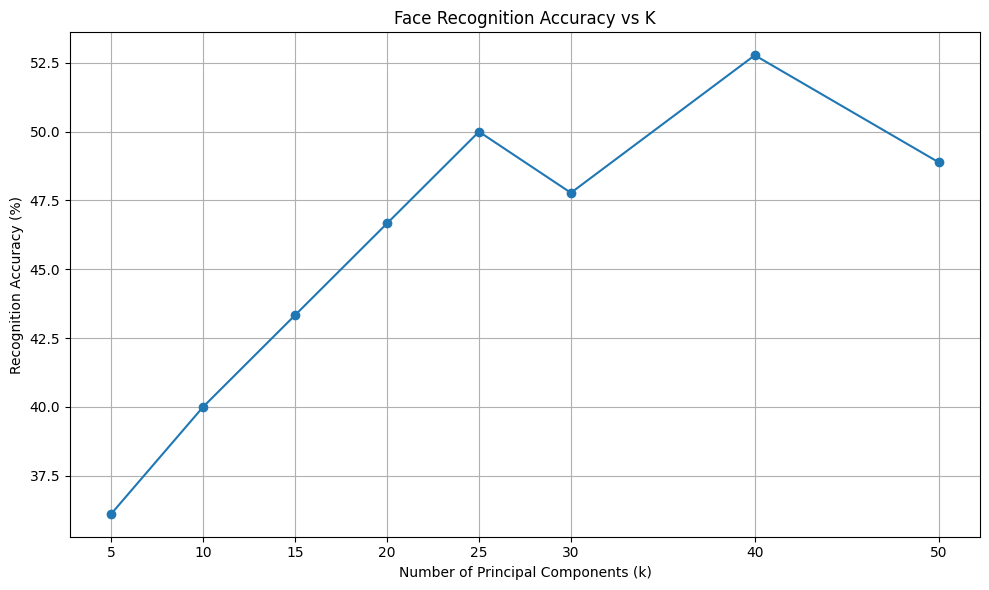

In [38]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    accuracies,
    marker='o'
)

plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Recognition Accuracy (%)")
plt.title("Face Recognition Accuracy vs K")

plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
best_index = np.argmax(accuracies)

best_k = k_values[best_index]
best_accuracy = accuracies[best_index]

print("Best K:", best_k)
print(f"Best Accuracy: {best_accuracy:.2f}%")

Best K: 40
Best Accuracy: 52.78%


In [41]:
import pandas as pd

In [42]:
results_df = pd.DataFrame({
    "K": k_values,
    "Accuracy (%)": accuracies
})

display(results_df)

,K,Accuracy (%)
0,5,36.111111
1,10,40.000000
2,15,43.333333
3,20,46.666667
4,25,50.000000
5,30,47.777778
6,40,52.777778
7,50,48.888889


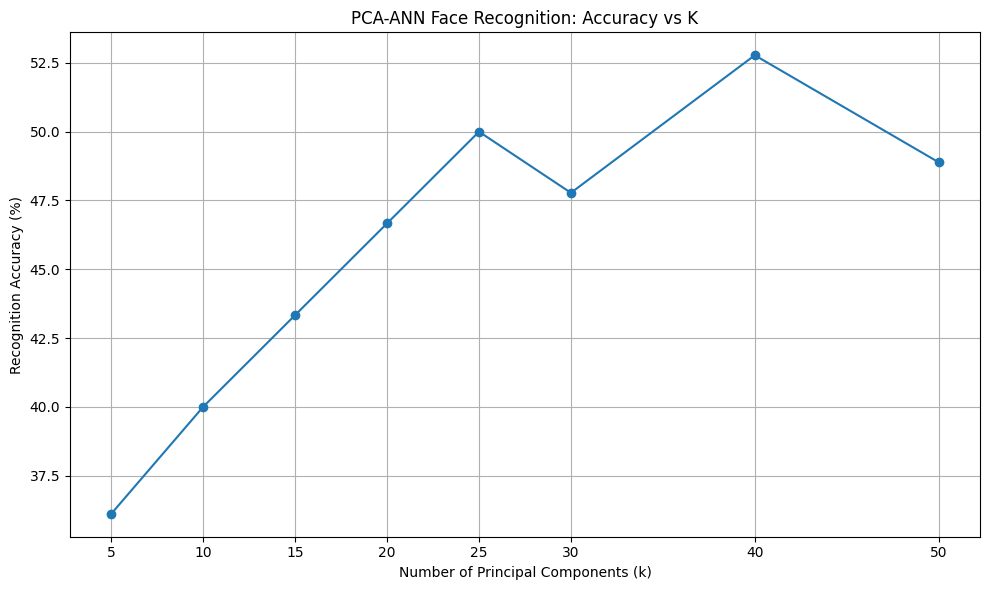

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Recognition Accuracy (%)")
plt.title("PCA-ANN Face Recognition: Accuracy vs K")

plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.savefig("accuracy_vs_k.png", dpi=300)
plt.show()

In [44]:
# Use the best K found from our experiments

best_index = np.argmax(accuracies)
best_k = k_values[best_index]

print("Best K:", best_k)
print(f"Best Accuracy: {accuracies[best_index]:.2f}%")

# Generate eigenfaces using best K
best_small_eigenvectors = sorted_eigenvectors[:, :best_k]

best_eigenfaces = np.dot(
    best_small_eigenvectors.T,
    X_train_centered
)

# Normalize eigenfaces
best_eigenfaces = best_eigenfaces / (
    np.linalg.norm(best_eigenfaces, axis=1, keepdims=True) + 1e-10
)

print("Best eigenfaces shape:", best_eigenfaces.shape)

Best K: 40
Best Accuracy: 52.78%
Best eigenfaces shape: (40, 10000)


In [45]:
# Final face signatures using the best K

final_train_signatures = np.dot(
    X_train_centered,
    best_eigenfaces.T
)

final_test_signatures = np.dot(
    X_test_centered,
    best_eigenfaces.T
)

print("Training signatures:", final_train_signatures.shape)
print("Testing signatures:", final_test_signatures.shape)

Training signatures: (270, 40)
Testing signatures: (180, 40)


In [46]:
# Final ANN model

final_ann = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

final_ann.fit(
    final_train_signatures,
    y_train
)

print("Final ANN training completed!")

Final ANN training completed!


In [47]:
# Final prediction

final_predictions = final_ann.predict(final_test_signatures)

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

print(f"Final Face Recognition Accuracy: {final_accuracy:.2f}")
print(f"Final Face Recognition Accuracy: {final_accuracy * 100:.2f}%")

Final Face Recognition Accuracy: 0.53
Final Face Recognition Accuracy: 52.78%


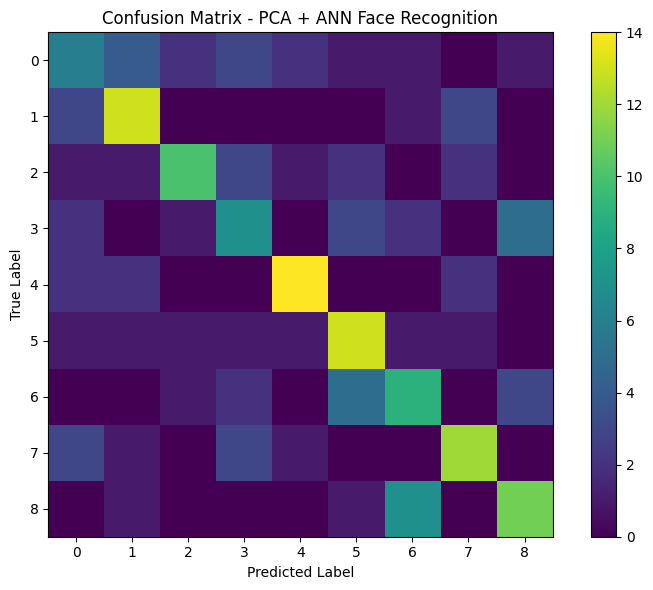

In [48]:
cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Confusion Matrix - PCA + ANN Face Recognition")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.tight_layout()
plt.show()

In [49]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[label_names[i] for i in sorted(label_names.keys())]
    )
)

Classification Report:

              precision    recall  f1-score   support

       Aamir       0.33      0.30      0.32        20
        Ajay       0.57      0.65      0.60        20
      Akshay       0.67      0.50      0.57        20
        Alia       0.37      0.35      0.36        20
     Amitabh       0.74      0.70      0.72        20
     Deepika       0.52      0.65      0.58        20
       Disha       0.43      0.45      0.44        20
      Farhan       0.60      0.60      0.60        20
      Ileana       0.55      0.55      0.55        20

    accuracy                           0.53       180
   macro avg       0.53      0.53      0.53       180
weighted avg       0.53      0.53      0.53       180



In [51]:
import os

# Check where the notebook is currently running
print("Current working directory:")
print(os.getcwd())

print("\nFolders/files here:")
print(os.listdir())

Current working directory:
C:\Users\HP\PCA_ANN_Face_Recognition

Folders/files here:
['.ipynb_checkpoints', 'accuracy_vs_k.png', 'imposter', 'PCA_ANN_Face_Recognition.ipynb']


In [52]:
IMPOSTER_PATH = r"C:\Users\HP\PCA_ANN_Face_Recognition\imposter"

print("Imposter folder exists:", os.path.exists(IMPOSTER_PATH))
print("Files:", os.listdir(IMPOSTER_PATH))

Imposter folder exists: True
Files: ['unknown1.jpg.jpg', 'unknown2.jpg.webp', 'unknown3.jpg.webp']


In [53]:
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

print("Supported image formats:", image_extensions)

Supported image formats: ('.jpg', '.jpeg', '.png', '.bmp', '.webp')


In [54]:
imposter_images = []
imposter_names = []

for file in os.listdir(IMPOSTER_PATH):
    if file.lower().endswith(image_extensions):

        image_path = os.path.join(IMPOSTER_PATH, file)

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            print("Could not read:", file)
            continue

        img = cv2.resize(img, IMG_SIZE)

        imposter_images.append(img.flatten())
        imposter_names.append(file)

imposter_images = np.array(imposter_images)

print("Number of imposter images:", len(imposter_images))
print("Imposter images shape:", imposter_images.shape)
print("Files:", imposter_names)

Number of imposter images: 3
Imposter images shape: (3, 10000)
Files: ['unknown1.jpg.jpg', 'unknown2.jpg.webp', 'unknown3.jpg.webp']


In [55]:
# Mean-center imposter faces

imposter_centered = imposter_images - mean_face

# Project imposter faces into PCA/eigenface space

imposter_signatures = np.dot(
    imposter_centered,
    best_eigenfaces.T
)

print("Imposter centered shape:", imposter_centered.shape)
print("Imposter signatures shape:", imposter_signatures.shape)

Imposter centered shape: (3, 10000)
Imposter signatures shape: (3, 40)


In [56]:
# ANN prediction for imposter faces

imposter_predictions = final_ann.predict(imposter_signatures)

print("ANN predictions for imposter faces:\n")

for file, prediction in zip(imposter_names, imposter_predictions):
    print(f"{file} -> {label_names[prediction]}")

ANN predictions for imposter faces:

unknown1.jpg.jpg -> Akshay
unknown2.jpg.webp -> Disha
unknown3.jpg.webp -> Disha


In [57]:
from scipy.spatial.distance import cdist

distances = cdist(
    imposter_signatures,
    final_train_signatures,
    metric='euclidean'
)

min_distances = np.min(distances, axis=1)

print("Minimum distance for each imposter:\n")

for file, distance in zip(imposter_names, min_distances):
    print(f"{file} -> {distance:.2f}")

Minimum distance for each imposter:

unknown1.jpg.jpg -> 5143.91
unknown2.jpg.webp -> 4447.29
unknown3.jpg.webp -> 3959.28


In [58]:
# Calculate distances between known training faces

known_distances = cdist(
    final_train_signatures,
    final_train_signatures,
    metric='euclidean'
)

# Ignore each face's distance to itself
np.fill_diagonal(known_distances, np.inf)

# Nearest known-face distance for every training image
nearest_known_distances = np.min(
    known_distances,
    axis=1
)

# Calculate threshold
threshold = (
    np.mean(nearest_known_distances)
    + 2 * np.std(nearest_known_distances)
)

print(f"Mean known distance: {np.mean(nearest_known_distances):.2f}")
print(f"Std known distance: {np.std(nearest_known_distances):.2f}")
print(f"Imposter threshold: {threshold:.2f}")

Mean known distance: 2956.00
Std known distance: 1512.66
Imposter threshold: 5981.31


In [59]:
imposter_results = pd.DataFrame({
    "Image": imposter_names,
    "Minimum Distance": min_distances,
    "Result": [
        "IMPOSTER / UNKNOWN" if d > threshold else "KNOWN PERSON"
        for d in min_distances
    ]
})

display(imposter_results)

,Image,Minimum Distance,Result
0,unknown1.jpg.jpg,5143.913764,KNOWN PERSON
1,unknown2.jpg.webp,4447.285574,KNOWN PERSON
2,unknown3.jpg.webp,3959.277306,KNOWN PERSON


In [60]:
# Calculate nearest training-face distance for each known test face

known_test_distances = cdist(
    final_test_signatures,
    final_train_signatures,
    metric='euclidean'
)

min_known_test_distances = np.min(
    known_test_distances,
    axis=1
)

print("Known test-face distance statistics:")
print(f"Minimum : {np.min(min_known_test_distances):.2f}")
print(f"Mean    : {np.mean(min_known_test_distances):.2f}")
print(f"Maximum : {np.max(min_known_test_distances):.2f}")

Known test-face distance statistics:
Minimum : 0.00
Mean    : 2525.19
Maximum : 4926.72


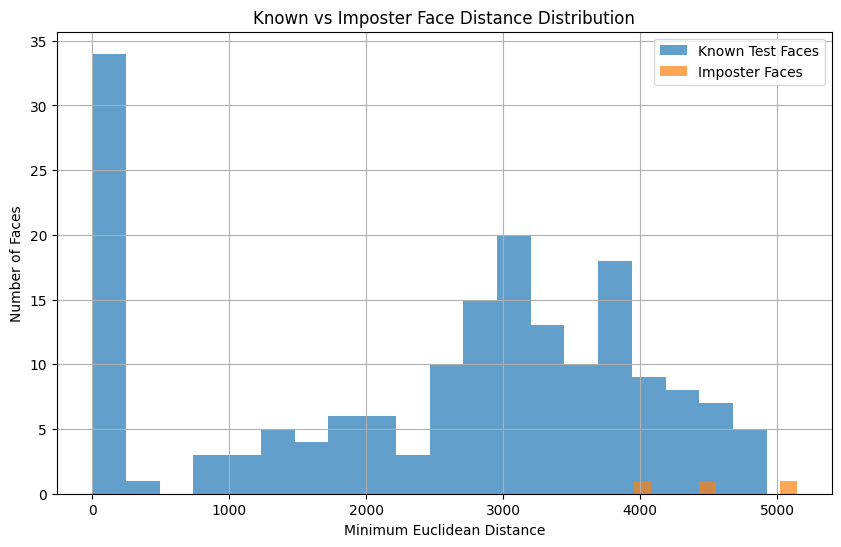

In [61]:
plt.figure(figsize=(10, 6))

plt.hist(
    min_known_test_distances,
    bins=20,
    alpha=0.7,
    label="Known Test Faces"
)

plt.hist(
    min_distances,
    bins=10,
    alpha=0.7,
    label="Imposter Faces"
)

plt.xlabel("Minimum Euclidean Distance")
plt.ylabel("Number of Faces")
plt.title("Known vs Imposter Face Distance Distribution")
plt.legend()
plt.grid(True)

plt.show()

In [62]:
# Calculate nearest training-face distance for each known test face

known_test_distances = cdist(
    final_test_signatures,
    final_train_signatures,
    metric='euclidean'
)

min_known_test_distances = np.min(
    known_test_distances,
    axis=1
)

print("Known test-face distance statistics:")
print(f"Minimum : {np.min(min_known_test_distances):.2f}")
print(f"Mean    : {np.mean(min_known_test_distances):.2f}")
print(f"Maximum : {np.max(min_known_test_distances):.2f}")

Known test-face distance statistics:
Minimum : 0.00
Mean    : 2525.19
Maximum : 4926.72


In [64]:
# Test several possible thresholds

candidate_thresholds = [
    3000,
    3500,
    4000,
    4500,
    5000,
    5500
]

print("Threshold analysis:\n")

for threshold in candidate_thresholds:

    known_accepted = np.sum(
        min_known_test_distances <= threshold
    )

    known_rejected = np.sum(
        min_known_test_distances > threshold
    )

    print(
        f"Threshold = {threshold:4d} | "
        f"Known accepted = {known_accepted:3d} | "
        f"Known rejected = {known_rejected:3d}"
    )

Threshold analysis:

Threshold = 3000 | Known accepted =  95 | Known rejected =  85
Threshold = 3500 | Known accepted = 125 | Known rejected =  55
Threshold = 4000 | Known accepted = 154 | Known rejected =  26
Threshold = 4500 | Known accepted = 168 | Known rejected =  12
Threshold = 5000 | Known accepted = 180 | Known rejected =   0
Threshold = 5500 | Known accepted = 180 | Known rejected =   0


In [65]:
print("\nImposter threshold analysis:\n")

for threshold in candidate_thresholds:

    imposter_rejected = np.sum(
        min_distances > threshold
    )

    print(
        f"Threshold = {threshold:4d} | "
        f"Imposters detected = {imposter_rejected}/{len(min_distances)}"
    )


Imposter threshold analysis:

Threshold = 3000 | Imposters detected = 3/3
Threshold = 3500 | Imposters detected = 3/3
Threshold = 4000 | Imposters detected = 2/3
Threshold = 4500 | Imposters detected = 1/3
Threshold = 5000 | Imposters detected = 1/3
Threshold = 5500 | Imposters detected = 0/3


In [67]:
fine_thresholds = [4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000]

print("Fine Threshold Analysis")
print("-" * 70)

for threshold in fine_thresholds:

    known_accepted = np.sum(
        min_known_test_distances <= threshold
    )

    known_rejected = np.sum(
        min_known_test_distances > threshold
    )

    imposter_detected = np.sum(
        min_distances > threshold
    )

    print(
        f"Threshold: {threshold:4d} | "
        f"Known accepted: {known_accepted:3d}/180 | "
        f"Known rejected: {known_rejected:3d} | "
        f"Imposters detected: {imposter_detected}/3"
    )

Fine Threshold Analysis
----------------------------------------------------------------------
Threshold: 4200 | Known accepted: 161/180 | Known rejected:  19 | Imposters detected: 2/3
Threshold: 4300 | Known accepted: 163/180 | Known rejected:  17 | Imposters detected: 2/3
Threshold: 4400 | Known accepted: 168/180 | Known rejected:  12 | Imposters detected: 2/3
Threshold: 4500 | Known accepted: 168/180 | Known rejected:  12 | Imposters detected: 1/3
Threshold: 4600 | Known accepted: 172/180 | Known rejected:   8 | Imposters detected: 1/3
Threshold: 4700 | Known accepted: 175/180 | Known rejected:   5 | Imposters detected: 1/3
Threshold: 4800 | Known accepted: 178/180 | Known rejected:   2 | Imposters detected: 1/3
Threshold: 4900 | Known accepted: 179/180 | Known rejected:   1 | Imposters detected: 1/3
Threshold: 5000 | Known accepted: 180/180 | Known rejected:   0 | Imposters detected: 1/3


In [68]:
final_threshold = 4000

final_imposter_results = []

for file, distance in zip(imposter_names, min_distances):

    if distance > final_threshold:
        result = "IMPOSTER / UNKNOWN"
    else:
        result = "NOT REJECTED"

    final_imposter_results.append({
        "Image": file,
        "Minimum Distance": round(distance, 2),
        "Result": result
    })

final_imposter_df = pd.DataFrame(final_imposter_results)

display(final_imposter_df)

,Image,Minimum Distance,Result
0,unknown1.jpg.jpg,5143.91,IMPOSTER / UNKNOWN
1,unknown2.jpg.webp,4447.29,IMPOSTER / UNKNOWN
2,unknown3.jpg.webp,3959.28,NOT REJECTED


## Conclusion

The PCA-ANN based face recognition system was successfully implemented
using the face database.

The system performed dimensionality reduction using Principal Component
Analysis (PCA), generated eigenfaces and face signatures, and used an
Artificial Neural Network (ANN) for face classification.

Different values of k were tested to study the effect of the number of
principal components on recognition accuracy.

An additional imposter detection experiment was performed using three
faces that were not part of the enrolled dataset. A distance-based
threshold was used for unknown-face rejection.

For the selected threshold of 4000, 2 out of 3 imposter faces were
detected, while some known faces were also rejected. This shows that
there is overlap between the known and unknown face distance
distributions.

Therefore, the system demonstrates successful PCA-based face
representation and ANN classification, while the imposter detection
results indicate that threshold tuning and a larger/more diverse
dataset could improve unknown-person rejection.

1. Introduction
2. Dataset Loading
3. Face Database Creation
4. Train/Test Split
5. Mean Face
6. Mean-Zero Data
7. Surrogate Covariance Matrix
8. Eigenvalues and Eigenvectors
9. Eigenfaces
10. Face Signatures
11. ANN Training
12. Accuracy for Different K
13. Accuracy vs K Graph
14. Confusion Matrix
15. Classification Report
16. Imposter Detection
17. Known vs Imposter Distance Graph
18. Final Results
19. Conclusion